<h1> Encoding Numerical Data</h1>

In [1]:
import pandas as pd 
import numpy as np

In [2]:
import matplotlib.pyplot as pyplot 

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic.csv', usecols=['Age', 'Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.dropna(inplace = True)           # dropping missing values which are there in age 
df.shape

(714, 3)

In [5]:
# Train Test split 
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 
X_train.shape, X_test.shape

((571, 2), (143, 2))

<h2 style="color:blue">Without Applying Discretization</h2>

In [7]:
dt = DecisionTreeClassifier() 

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Accuracy : ", accuracy_score(y_pred, y_test))

# Cross checking by cross_val_score
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, scoring='accuracy', cv=5))

Accuracy :  0.6293706293706294


np.float64(0.6316458189697627)

<h2 style="color:blue">Applying Discretization</h2>

In [21]:
kbin_age = KBinsDiscretizer(n_bins=10, strategy='quantile',encode='ordinal')
kbin_Fare = KBinsDiscretizer(n_bins=10, strategy='quantile', encode='ordinal')

In [22]:
# Column Transformer 
tnf = ColumnTransformer(
        transformers=[
                      ('tnf1',kbin_age, [0]),
                      ('tnf2',kbin_Fare, [1])
                     ], 
        remainder='passthrough'
    )

In [23]:
X_train_tnf = tnf.fit_transform(X_train)
X_test_tnf = tnf.transform(X_test) 

In [27]:
# tnf.named_transformers_
tnf.named_transformers_['tnf1'].n_bins_       # no. of bins in 'tnf1' feature

array([10])

In [30]:
tnf.named_transformers_['tnf1'].bin_edges_      # edges of each bins, for Quantile binning

array([array([ 0.67, 14.  , 18.  , 22.  , 25.  , 28.  , 31.  , 35.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [34]:
output = pd.DataFrame({
    'age':X_train['Age'], 
    'age_tnf':X_train_tnf[:, 0], 
    'fare' : X_train['Fare'],
    'fare_tnf' : X_train_tnf[:, 1]
})

In [36]:
# pd.cut() converts continuous numerical values into categorical intervals (bins).
# to see the actual bin ranges created by KBinsDiscretizer

output['age_labels'] = pd.cut(
                            #  x: original continuous Age values (not transformed)
                            x=X_train['Age'],  
                            # bins: exact bin boundaries learned by KBinsDiscretizer during fitting
                            # trf.named_transformers_['first'] → fitted transformer for Age
                            # .bin_edges_ → array of bin boundaries
                            # [0] → first (and only) feature's bin edges
                            # .tolist() → convert NumPy array to Python list (pd.cut requires this)
                            bins = tnf.named_transformers_['tnf1'].bin_edges_[0].tolist()
      )

output['fare_labels'] = pd.cut(
                               x = X_train['Fare'],
                               bins= tnf.named_transformers_['tnf2'].bin_edges_[0].tolist()
      )

In [41]:
output.sample(5)

,age,age_tnf,fare,fare_tnf,age_labels,fare_labels
835,39.0,7.0,83.1583,9.0,"(35.0, 42.0]","(78.267, 512.329]"
268,58.0,9.0,153.4625,9.0,"(50.0, 80.0]","(78.267, 512.329]"
816,23.0,3.0,7.9250,2.0,"(22.0, 25.0]","(7.896, 8.662]"
369,24.0,3.0,69.3000,8.0,"(22.0, 25.0]","(39.688, 78.267]"
763,36.0,7.0,120.0000,9.0,"(35.0, 42.0]","(78.267, 512.329]"


In [48]:
dt = DecisionTreeClassifier()

dt.fit(X_train_tnf, y_train) 
y_pred2 = dt.predict(X_test_tnf)

print("Accuracy :", accuracy_score(y_pred2, y_test))
X_tnf = tnf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X_tnf, y, scoring='accuracy', cv=10))

Accuracy : 0.6993006993006993


np.float64(0.682140062597809)

<h2 style="color:blue">Function for Discretization</h2>

In [61]:
def discretize(strategy, bins): 
    kbin_age = KBinsDiscretizer(n_bins=bins, strategy=strategy, encode='ordinal')
    kbin_fare = KBinsDiscretizer(n_bins=bins, strategy=strategy, encode='ordinal')

    tnf = ColumnTransformer(transformers=[
            ('tnf1',kbin_age,[0]),
            ('tnf2',kbin_fare, [1])
    ])
    X_tnf = tnf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X_tnf, y, scoring='accuracy', cv=10)))

    pyplot.figure(figsize=(12,4))
    pyplot.subplot(221)
    pyplot.hist(x=X['Age'])
    pyplot.title('Before')
    
    pyplot.subplot(222)
    pyplot.hist(x=X_tnf[:, 0], color='red')
    pyplot.title('After')
    
    pyplot.subplot(223)
    pyplot.hist(x=X['Fare'], color='pink')
    pyplot.title('Before')
    
    pyplot.subplot(224)
    pyplot.hist(x=X_tnf[:, 1], color='green')
    pyplot.title('After')
    pyplot.show()

C:\Users\rupes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\rupes\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6723982785602504


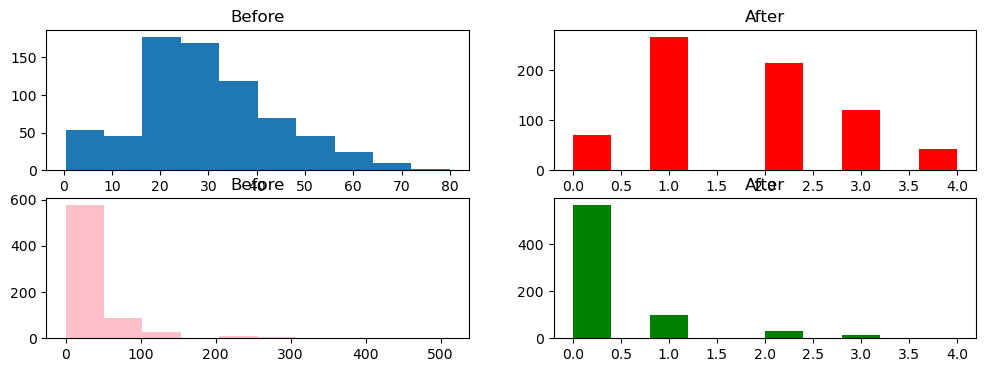

In [64]:
discretize('kmeans',5)

<h2 style="color:blue">Custom/Domain Based Binning</h2>

<h2 style="color:blue">Binarization</h2>

In [66]:
# converting a continous value/ numerical value into Binary form (0, 1)
# Annual income     >5L -> 1
#                  <=5L -> 0 

# Image Processing 
# color image (0-255)pixel  ->  Black & white image (   >127.5 -> 1,      <127.5 -> 0) 

In [77]:
# sklearn.preprocessing.Binarizer(threshold=0.0, copy=True)
from sklearn.preprocessing import Binarizer
# threshold : float, default=0.0
# Feature values below or equal to this are replaced by 0, above it by 1. Threshold may not be less than 0 for operations on sparse matrices.

# copy : bool, default=True
# Set to False to perform inplace binarization and avoid a copy (if the input is already a numpy array or a scipy.sparse CSR matrix).

# Create a Binarizer object
# threshold = 21 → values > 21 become 1, values ≤ 21 become 0
# copy = False → modify data in-place (no extra copy)
bin = Binarizer(threshold=21, copy=False)

df['Adult'] = bin.fit_transform(df[['Age']])              # # [['Age']] keeps the data 2D (required by sklearn)
df

,Survived,Age,Fare,Adult
0,0,22.0,7.2500,1.0
1,1,38.0,71.2833,1.0
2,1,26.0,7.9250,1.0
3,1,35.0,53.1000,1.0
4,0,35.0,8.0500,1.0
...,...,...,...,...
885,0,39.0,29.1250,1.0
886,0,27.0,13.0000,1.0
887,1,19.0,30.0000,0.0
889,1,26.0,30.0000,1.0
